In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# fetch dataset 
credit_approval = fetch_ucirepo(id=27) 
  
# data (as pandas dataframes) 
x = credit_approval.data.features 
y = credit_approval.data.targets 
df=pd.concat([x,y],axis=1)
credit=pd.DataFrame(df)
credit=credit.reset_index(drop=True)
credit.head()

,A15,A14,A13,A12,A11,A10,A9,A8,A7,A6,A5,A4,A3,A2,A1,A16
0,0,202.0,g,f,1,t,t,1.25,v,w,g,u,0.000,30.83,b,+
1,560,43.0,g,f,6,t,t,3.04,h,q,g,u,4.460,58.67,a,+
2,824,280.0,g,f,0,f,t,1.50,h,q,g,u,0.500,24.50,a,+
3,3,100.0,g,t,5,t,t,3.75,v,w,g,u,1.540,27.83,b,+
4,0,120.0,s,f,0,f,t,1.71,v,w,g,u,5.625,20.17,b,+


In [3]:
credit.info()
(credit=="nan").sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A15     690 non-null    int64  
 1   A14     677 non-null    float64
 2   A13     690 non-null    object 
 3   A12     690 non-null    object 
 4   A11     690 non-null    int64  
 5   A10     690 non-null    object 
 6   A9      690 non-null    object 
 7   A8      690 non-null    float64
 8   A7      681 non-null    object 
 9   A6      681 non-null    object 
 10  A5      684 non-null    object 
 11  A4      684 non-null    object 
 12  A3      690 non-null    float64
 13  A2      678 non-null    float64
 14  A1      678 non-null    object 
 15  A16     690 non-null    object 
dtypes: float64(4), int64(2), object(10)
memory usage: 86.4+ KB


A15    0
A14    0
A13    0
A12    0
A11    0
A10    0
A9     0
A8     0
A7     0
A6     0
A5     0
A4     0
A3     0
A2     0
A1     0
A16    0
dtype: int64

In [4]:
#credit.isnull().sum()
#credit=credit.dropna()
credit.isnull().sum()
#credit[credit.isna().any(axis=1)]

A15     0
A14    13
A13     0
A12     0
A11     0
A10     0
A9      0
A8      0
A7      9
A6      9
A5      6
A4      6
A3      0
A2     12
A1     12
A16     0
dtype: int64

**checking unique values**

In [5]:
#for col in credit.columns:
    #print("column:",col)
    #print(credit[col].unique())

In [6]:
credit['A12'].value_counts()

A12
f    374
t    316
Name: count, dtype: int64

In [7]:
for col in credit.columns:
    count=( credit[col]== "nan").sum()
    if count > 0:
        print(col,":",count)

In [8]:
credit[credit.eq("nan").any(axis=1)]

,A15,A14,A13,A12,A11,A10,A9,A8,A7,A6,A5,A4,A3,A2,A1,A16


In [9]:
#converting nan to actuall NaN
credit.replace("nan",np.nan,inplace=True)

In [10]:
credit[credit.eq("nan").any(axis=1)]

,A15,A14,A13,A12,A11,A10,A9,A8,A7,A6,A5,A4,A3,A2,A1,A16


In [11]:
#credit.isna().sum()

In [12]:
(credit=="nan").sum()

A15    0
A14    0
A13    0
A12    0
A11    0
A10    0
A9     0
A8     0
A7     0
A6     0
A5     0
A4     0
A3     0
A2     0
A1     0
A16    0
dtype: int64

In [13]:
#credit[credit.isna().any(axis=1)]
#print(credit.isna().sum())

**sepearte features and target values**


In [14]:
x=credit.iloc[:,:-1]
y=credit.iloc[:,-1]


**encoding**

In [15]:
from sklearn.preprocessing import LabelEncoder

In [16]:
le=LabelEncoder()
for col in x.columns:
    if(x[col].dtype=='object'):
        x[col]=le.fit_transform(x[col].astype(str))
        

In [17]:
y=le.fit_transform(y)

**handling missing values**

In [18]:
from sklearn.impute import SimpleImputer

In [19]:
impute=SimpleImputer(strategy='mean')
x=impute.fit_transform(x)

In [20]:
x=pd.DataFrame(x)
x.isna().sum()
y=pd.DataFrame(y)
y.isna().sum()
corr=x.corr()

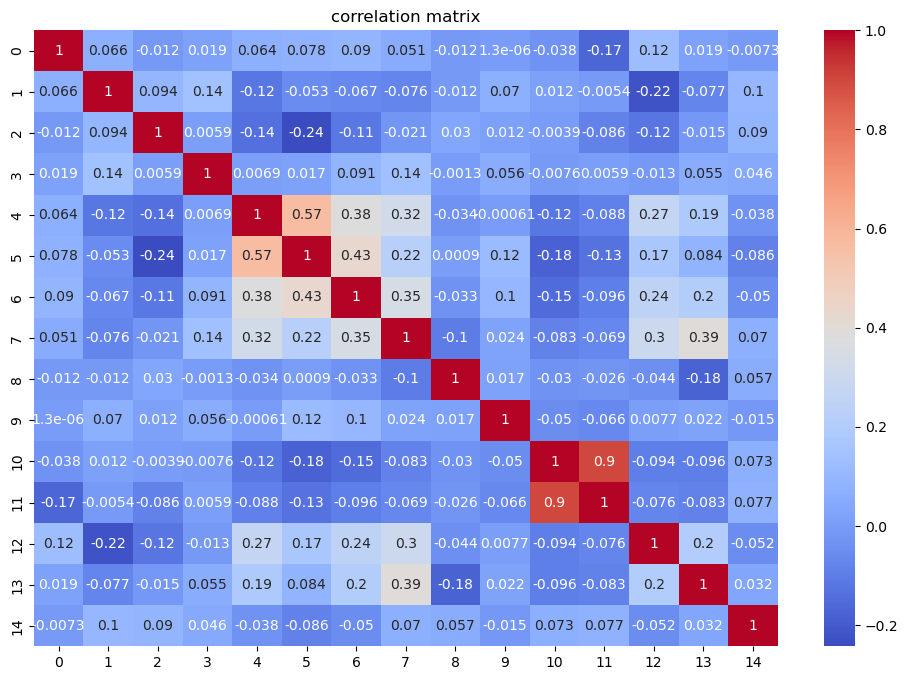

In [21]:
plt.figure(figsize=(12,8))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("correlation matrix")
plt.show()

In [22]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       690 non-null    int64
dtypes: int64(1)
memory usage: 5.5 KB


**Sclaing**

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler=StandardScaler()
x=scaler.fit_transform(x)

**Splitting data**

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("\ntrained set",x_train.shape)
print("\ny trained set",y_train.shape)
print("\nx test set",x_train.shape)
print("\ny test set",y_test.shape)


trained set (552, 15)

y trained set (552, 1)

x test set (552, 15)

y test set (138, 1)



**Logistc regression**

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
model=LogisticRegression()
model.fit(x_train,y_train)

D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

**training score**

In [29]:
train_score=model.score(x_train,y_train)*100
print("\ntrain score is:",train_score)


train score is: 87.86231884057972


**testing score**

In [30]:
test_score=model.score(x_test,y_test)*100
print("\ntesting score is:",test_score)


testing score is: 85.5072463768116


In [31]:
y_pred=model.predict(x_test)
print("\npredicted value",y_pred)


predicted value [1 0 1 1 1 1 1 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 0 1 1 0 0 1 1 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 1 0 1 1 1 1 1 1 1 1 0 1 0 1 0 1 0 0 0 1 1 0 0 1 0 1 1 0 1 0
 1 1 1 0 0 1 0 0 1 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 0 0 0 0 0 1 0 1 0 1
 0 0 1 0 1 0 0 1 0 1 1 0 1 1 1 1 1 0 0 0 1 0 1 0 0 0 0]


In [32]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,roc_auc_score,roc_curve,auc

In [33]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[60 10]
 [10 58]]


In [34]:
classifi_report=classification_report(y_test,y_pred)
print(classifi_report)

              precision    recall  f1-score   support

           0       0.86      0.86      0.86        70
           1       0.85      0.85      0.85        68

    accuracy                           0.86       138
   macro avg       0.86      0.86      0.86       138
weighted avg       0.86      0.86      0.86       138



In [35]:
accu_score=accuracy_score(y_test,y_pred)*100
print(accu_score,"%")

85.5072463768116 %


In [36]:
roc=roc_auc_score(y_test,y_pred)*100
print(roc,"%")

85.50420168067228 %


**confusion matrix visulixation**

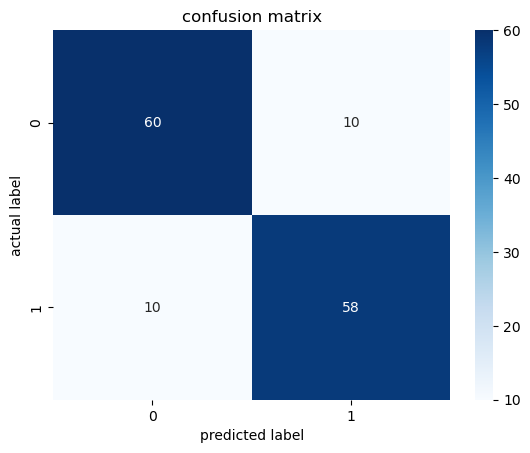

In [37]:
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("predicted label")
plt.ylabel("actual label")
plt.title("confusion matrix")
plt.show()

**Roc curve visulazation**

In [38]:
y_prob=model.predict_proba(x_test)[:,-1]
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
roc_auc=auc(fpr,tpr)

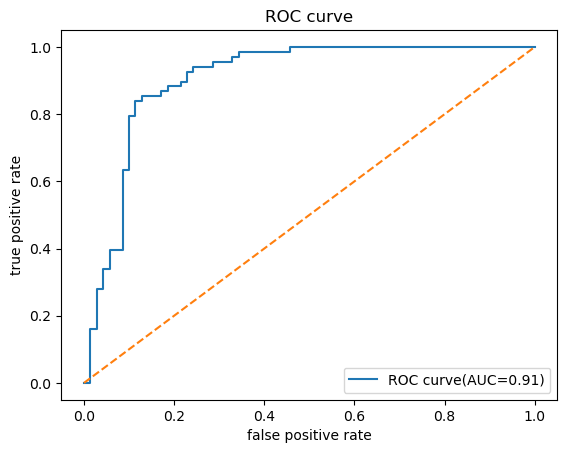

In [39]:
plt.plot(fpr,tpr,label="ROC curve(AUC=%0.2f)"%roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC curve")
plt.legend()
plt.show()